In [43]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Setup

Loading the cleaned, feature-engineered AirPassengers dataset alongside LightGBM, the tools for hyperparameter search (`TimeSeriesSplit`, `RandomizedSearchCV`), our evaluation metrics, and interpretability tools (`permutation_importance`, `PartialDependenceDisplay`).

In [44]:

import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import joblib
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [45]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [46]:
print(df.shape)
print(df.info())
print(df.describe())
df.head()

(144, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    144 non-null    int64  
 1   month          144 non-null    int32  
 2   quarter        144 non-null    int32  
 3   lag1           143 non-null    float64
 4   lag2           142 non-null    float64
 5   lag3           141 non-null    float64
 6   rolling_mean3  142 non-null    float64
 7   rolling_std3   142 non-null    float64
 8   rolling_mean6  139 non-null    float64
 9   rolling_std6   139 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 11.2 KB
None
       #Passengers       month     quarter        lag1        lag2  \
count   144.000000  144.000000  144.000000  143.000000  142.000000   
mean    280.298611    6.500000    2.500000  279.237762  278.457746   
std     119.966317    3.464102    1.121936  119.70827

,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


## Index integrity and missing values

Checking that the `DatetimeIndex` has a proper frequency and no duplicates, then backfilling the handful of NaNs that come from the start of the lag/rolling-window columns (there's no prior data to compute them from at the very beginning of the series).

In [47]:
print(df.index.freq)
print(df.isnull().sum())
print(df.index.duplicated().sum())
df.bfill(inplace=True)
print(df.isnull().sum())
print(df.shape)
df.head()

<MonthBegin>
#Passengers      0
month            0
quarter          0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64
0
#Passengers      0
month            0
quarter          0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64
(144, 10)


,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-02-01,118,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-03-01,132,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277


## Adding a ratio feature for multiplicative seasonality

Unlike SARIMAX or ETS, tree-based models don't have a built-in way to represent "seasonal swings that grow proportionally with the trend" (multiplicative seasonality) — they only see raw feature values and split on thresholds. Since the AirPassengers series clearly has multiplicative seasonality (bigger swings as volume grows), we give LightGBM a feature that directly encodes that: the ratio of the most recent observation to its recent rolling average.

A ratio near 1.0 means "in line with the recent trend"; a ratio noticeably above or below 1.0 signals a seasonal peak or trough relative to the current level - which is exactly the multiplicative pattern a raw lag value alone can't express.

In [48]:
df['lag1_ratio_rolling6'] = df['lag1'] / df['rolling_mean6']

## Train/test split and feature/target separation

Holding out the last 12 months (one full seasonal cycle) as the test set, same as in the other models, so results are directly comparable. `#Passengers` is the target; everything else (calendar features, lags, rolling stats, and the new ratio feature) is used as input.

In [49]:
train,test= df.iloc[:-12,:], df.iloc[-12:,:]
x_train,y_train= train.drop(columns=['#Passengers']), train['#Passengers']
x_test,y_test= test.drop(columns=['#Passengers']), test['#Passengers']

print(x_train.shape)
print(x_test.shape)
x_train.head()

(132, 10)
(12, 10)


,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,lag1_ratio_rolling6
Month,,,,,,,,,,
1949-01-01,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,0.899598
1949-02-01,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,0.899598
1949-03-01,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,0.947791
1949-04-01,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277,1.060241
1949-05-01,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277,1.036145


In [50]:
print(x_train.isnull().sum())
print(x_train.index.duplicated().sum())
print(x_train.info())
x_train.describe()

month                  0
quarter                0
lag1                   0
lag2                   0
lag3                   0
rolling_mean3          0
rolling_std3           0
rolling_mean6          0
rolling_std6           0
lag1_ratio_rolling6    0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 1949-01-01 to 1959-12-01
Freq: MS
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                132 non-null    int32  
 1   quarter              132 non-null    int32  
 2   lag1                 132 non-null    float64
 3   lag2                 132 non-null    float64
 4   lag3                 132 non-null    float64
 5   rolling_mean3        132 non-null    float64
 6   rolling_std3         132 non-null    float64
 7   rolling_mean6        132 non-null    float64
 8   rolling_std6         132 non-null    float64
 9   lag1_ratio_rolling6  132 non-null    float64
dt

,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,lag1_ratio_rolling6
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,6.500000,2.500000,260.272727,258.378788,256.143939,260.497475,22.221943,257.125000,31.101530,1.011810
std,3.465203,1.122293,106.686248,107.084865,107.037778,104.302534,15.758140,100.536507,18.653370,0.104049
min,1.000000,1.000000,104.000000,104.000000,104.000000,112.333333,1.154701,119.666667,8.916277,0.772881
25%,3.750000,1.750000,172.000000,171.750000,170.750000,172.000000,10.503055,172.458333,17.392215,0.949691
50%,6.500000,2.500000,237.000000,236.500000,235.500000,240.833333,19.118014,241.083333,24.837234,1.018133
75%,9.250000,3.250000,340.500000,337.750000,336.250000,336.750000,28.151981,341.916667,40.419085,1.096086
max,12.000000,4.000000,559.000000,559.000000,559.000000,526.333333,76.872188,478.166667,81.321584,1.200000


## Baseline LightGBM

Fitting with default hyperparameters first, before any tuning. This is a small dataset (132 training rows), so it's worth watching for `LightGBM [Warning] No further splits with positive gain` messages during training - that's a sign the default tree complexity (`num_leaves=31`, `min_child_samples=20`) is oversized for how little data we have, and it's a preview of why tuning below matters.

In [51]:
model = LGBMRegressor(force_col_wise=True,random_state=42)
model.fit(x_train, y_train)

LGBMRegressor(force_col_wise=True, random_state=42)

In [52]:
pred= model.predict(x_test)
pred= pd.Series(pred, index= x_test.index)

In [53]:
pred

Month
1960-01-01    439.852848
1960-02-01    416.223022
1960-03-01    423.318455
1960-04-01    434.529106
1960-05-01    449.989154
1960-06-01    460.698689
1960-07-01    488.886601
1960-08-01    488.515237
1960-09-01    434.132775
1960-10-01    387.637978
1960-11-01    387.637978
1960-12-01    385.953040
Freq: MS, dtype: float64

In [54]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= mean_absolute_percentage_error(test, predictions)
  mape= round(mape * 100, 2)
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

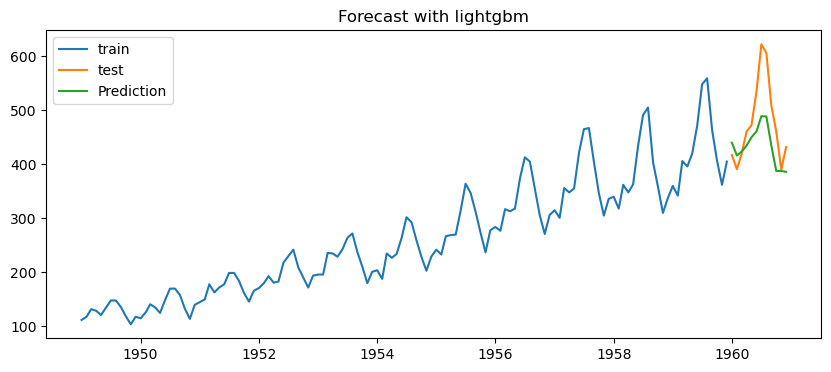

mean absolute error: 51.78
mean absolute percentage error: 9.98%
r2 score: 0.21
root mean squared error: 66.06


,mae,mape,r2,rmse
0,51.78,9.98,0.21,66.06


In [55]:
model_evaluator(y_train,y_test,pred, 'lightgbm')

## Fine-tuning LightGBM

Using `TimeSeriesSplit` (not a regular k-fold) so every validation fold still respects chronological order - no training on the future to predict the past. `RandomizedSearchCV` samples 40 combinations from the grid below rather than trying all of them, which keeps runtime reasonable while still covering the space of tree depth, leaf count, regularization, and subsampling that controls how much the model can overfit on a dataset this small.

In [56]:
# Fine tuning lightgbm

split= TimeSeriesSplit(n_splits=5)
param_grid={
    "num_leaves": list(range(5,16,2)),
    "max_depth": list(range(2,6)),
    "n_estimators": list(range(100,5000,100)),
    "min_child_samples": list(range(2, 11,2)),
    "subsample": list(np.arange(0.6, 1.0, 0.1)),
    "colsample_bytree": list(np.arange(0.5, 1.0, 0.1)),
    "reg_alpha": list(np.arange(0.0, 1.0, 0.25)),
    "reg_lambda": list(np.arange(0.0, 2.0, 0.25)),
}
model= LGBMRegressor(force_col_wise=True,
                    random_state=42,
                    verbosity=-1)

grid= RandomizedSearchCV(model, param_grid,cv=split,n_iter=40, n_jobs=-1, scoring='neg_mean_absolute_error',verbose=1)

In [57]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=LGBMRegressor(force_col_wise=True, random_state=42,
                                           verbosity=-1),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.6, 0.7,
                                                             0.7999999999999999,
                                                             0.8999999999999999],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_child_samples': [2, 4, 6, 8, 10],
                                        'n_estimators': [10...0,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100, 1200,
                                                         1300, 1400, 1500, 1600,
                                                         1700, 1800, 1900, 2000,
                                                         2100, 2200, 2300, 2400,
                                                         2500, 2600, 2700, 2800,
                                                         2900, 3000, ...],
                                        'num_leaves': [5, 7, 9, 11, 13, 15],
                                        'reg_alpha': [0.0, 0.25, 0.5, 0.75],
                                        'reg_lambda': [0.0, 0.25, 0.5, 0.75,
                                                       1.0, 1.25, 1.5, 1.75],
                                        'subsample': [0.6, 0.7,
                                                      0.7999999999999999,
                                                      0.8999999999999999]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [58]:
grid.best_score_

-26.401487662129483

In [59]:
param= grid.best_params_
param

{'subsample': 0.7,
 'reg_lambda': 0.0,
 'reg_alpha': 0.5,
 'num_leaves': 7,
 'n_estimators': 3500,
 'min_child_samples': 2,
 'max_depth': 4,
 'colsample_bytree': 0.7999999999999999}

In [60]:
pred= grid.predict(x_test)
pred= pd.Series(pred, index=x_test.index)
pred

Month
1960-01-01    427.543641
1960-02-01    416.242004
1960-03-01    418.988098
1960-04-01    454.923424
1960-05-01    478.031281
1960-06-01    499.764801
1960-07-01    562.266924
1960-08-01    555.712407
1960-09-01    471.313194
1960-10-01    458.518473
1960-11-01    424.374537
1960-12-01    388.144664
Freq: MS, dtype: float64

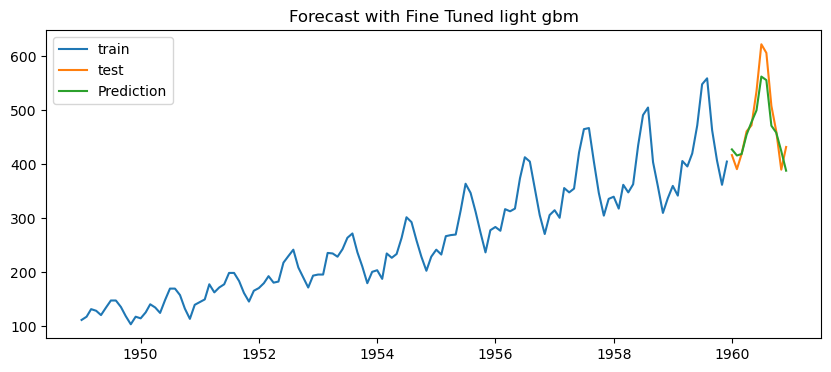

mean absolute error: 25.88
mean absolute percentage error: 5.23%
r2 score: 0.81
root mean squared error: 32.43


In [61]:
lgbm_metric=model_evaluator(y_train,y_test,pred, 'Fine Tuned light gbm')

In [62]:
lgbm_metric.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\lgbm_metric.csv')

## Final model

Refitting on the *entire* dataset (not just `train`) using the tuned hyperparameters, now that the model choice is validated. Keeping the same `random_state`, `force_col_wise`, and `verbosity` settings as the earlier models for reproducibility and consistent output.

In [63]:
# final model

final_model= LGBMRegressor(**param,random_state=42, force_col_wise=True, verbosity=-1)
final_model.fit(df.drop(columns=['#Passengers']), df['#Passengers'])

LGBMRegressor(colsample_bytree=0.7999999999999999, force_col_wise=True,
              max_depth=4, min_child_samples=2, n_estimators=3500, num_leaves=7,
              random_state=42, reg_alpha=0.5, subsample=0.7, verbosity=-1)

In [64]:
future_data= pd.date_range(start= '1961-01-01' , freq='MS', periods=12)
future_data= pd.Series(index= future_data)
future_data.index

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [65]:

def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):
 
    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_data.index:

        month_number = date.month
        quarter_number =date.quarter

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]


        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history
        last_12_months = history.iloc[-12:] if len(history) >= 12 else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0


        lag1_ratio_rolling6 = lag1 / rolling_mean_6 if rolling_mean_6 != 0 else 1.0
      

        one_row = pd.DataFrame({
            "month": [month_number],
            "quater": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
            "lag1_ratio_rolling6": [lag1_ratio_rolling6],
           
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

   
    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_data.index, name=target_col)

    return future_exog, forecast

In [66]:
history = df["#Passengers"]

future_exog, forecast = build_exog_row(final_model, history, future_data)


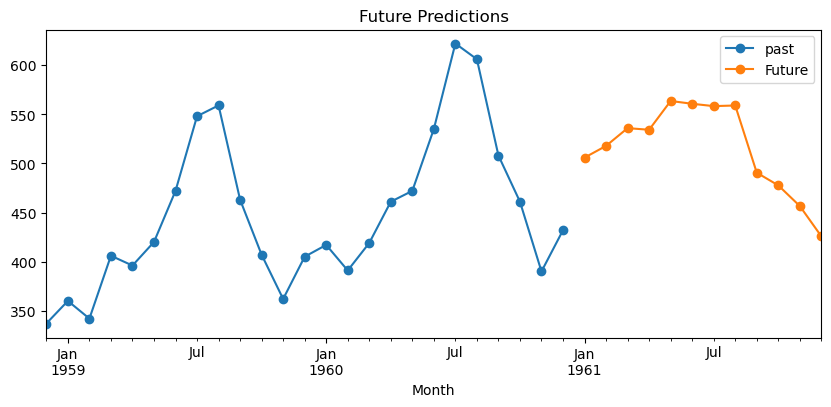

In [67]:
plt.figure(figsize=(10,4))
df['#Passengers'].iloc[-25:].plot(label='past', marker='o')
forecast.plot(label='Future',marker='o')

plt.legend()
plt.title('Future Predictions')
plt.show()

## Saving the model

Persisting the final fitted model for later inference and for the cross-model comparison notebook.

In [68]:
joblib.dump(final_model, r"C:\Users\MINE\Desktop\Air passenger prediction\models\lightgbm.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\lightgbm.pkl']

## Feature importance

LightGBM's built-in importance (by default, how often a feature is used to split) is a fast first look, but it tends to favor continuous, high-cardinality features (lags, rolling stats) over low-cardinality ones (`month`, `quater`) simply because there are more places to split on them - not necessarily because they matter more. Treat this as a first pass, not the final word; permutation importance below is a more reliable second opinion.

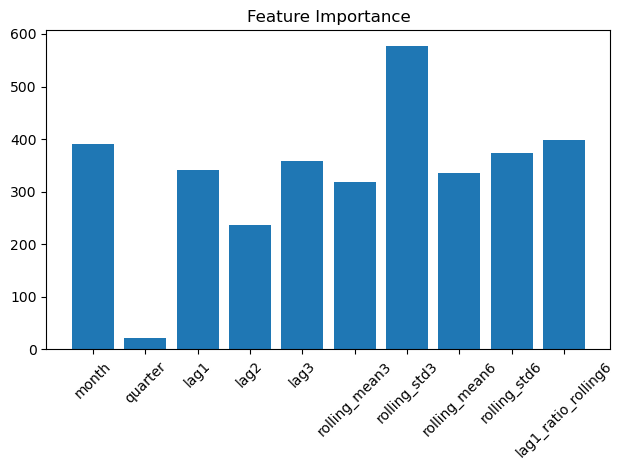

In [69]:
# Feature importance

importance= final_model.feature_importances_

plt.bar( x_train.columns, importance)

plt.title('Feature Importance')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

## Permutation importance

This shuffles one feature at a time in the test set and measures how much the model's error gets worse - a more trustworthy measure of "how much does this feature actually help predict," independent of how often it was used to build splits. Error bars (`std`) show how consistent that effect was across 30 repeats; a feature with a wide std is a less reliable signal than one with a tight one, even at the same mean importance.

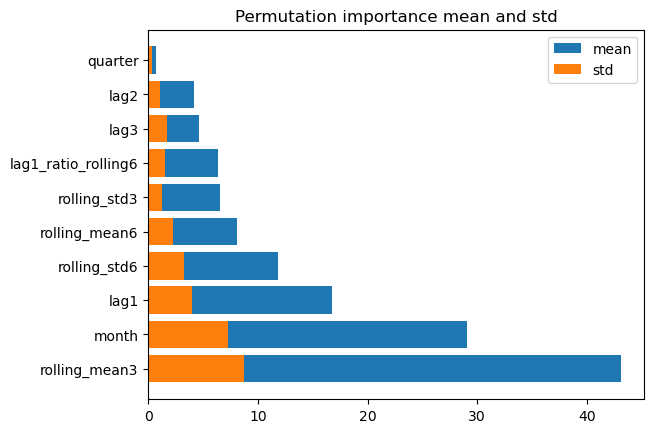

In [70]:
# Permutation importance 

p_imp= permutation_importance(final_model,x_test,y_test,
                              scoring='neg_mean_absolute_error',
                              n_repeats= 30,
                              n_jobs= -1)
values= {
  'features': x_test.columns,
  'mean': p_imp.importances_mean,
  'std': p_imp.importances_std
}
p_imp= pd.DataFrame(values)
p_imp=p_imp.sort_values('mean', ascending=False)
plt.barh(p_imp['features'], p_imp['mean'], label='mean')
plt.barh(p_imp['features'], p_imp['std'], label='std')

plt.legend()
plt.title('Permutation importance mean and std')
plt.show()

## Partial dependence

Shows how the model's prediction changes as each feature varies, holding the others at their observed distribution - useful for checking the model learned sensible relationships (e.g. does `month` show the expected summer peak?) rather than just trusting the error metrics.

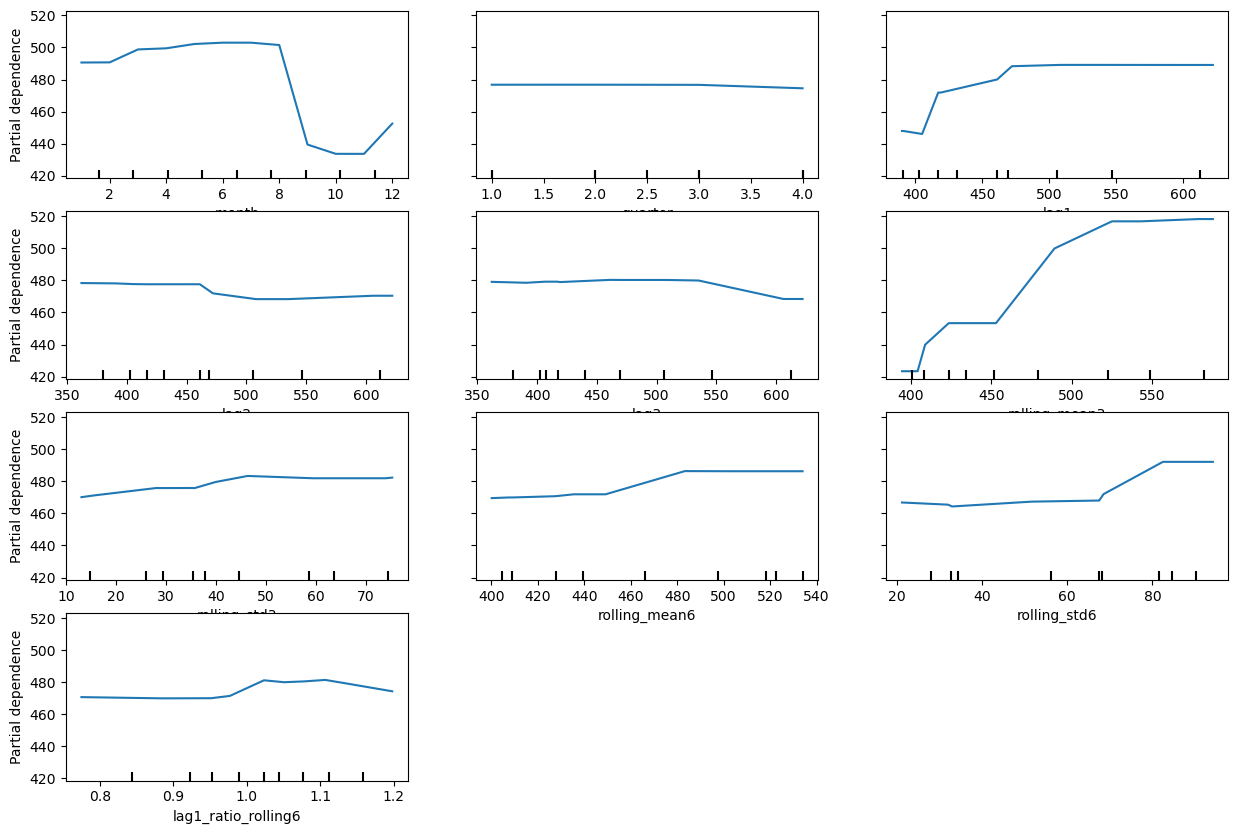

In [71]:
# partial dependency

fig,axes= plt.subplots(figsize=(15,10))

PartialDependenceDisplay.from_estimator(
                final_model, x_test,
                features= list(x_test.columns),
                feature_names= list(x_test.columns),
                grid_resolution= 50,
                n_cols= 3,
                ax= axes
)
plt.show()